In [1]:
# Import necessary libraries
from pyhgf.model import Network
from jax.typing import ArrayLike
from scipy.stats import halfnorm, norm

# Import JAX and related modules
import jax
import jax.numpy as jnp
from jax import random
from jax.tree_util import Partial
from jax import vmap

# Import other necessary libraries
import copy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time
import numpy as np
from scipy.stats import norm, halfnorm
import matplotlib.pyplot as plt
import numpy as np
import colorsys

from plot import plot_distributions, plot_kl_divergences, plot_time_series, plot_trajectories, plot_proportions
from environement import generate_observations
from voting import get_votes

Contenu de candidates:
[((np.float64(3.4803253501632936), np.float64(1.4124754395890273)), (np.float64(-1.5557481788072502), np.float64(1.4206516362547514)), (np.float64(0.2986560684723145), np.float64(3.6011426851043917))), ((np.float64(2.570687483164932), np.float64(1.0639930594778384)), (np.float64(1.423816834046359), np.float64(0.5421718932293375)), (np.float64(0.4471028861012214), np.float64(0.3959969106240672))), ((np.float64(1.2773621444708323), np.float64(1.3243254848564134)), (np.float64(1.9658229921671935), np.float64(2.1867413180368453)), (np.float64(3.023788135355267), np.float64(1.0316046516816861))), ((np.float64(1.5819836545034398), np.float64(0.4196320583784076)), (np.float64(1.6630945555601682), np.float64(0.12287976077801449)), (np.float64(1.994381618464477), np.float64(0.3504901263390535))), ((np.float64(1.0097430134198329), np.float64(0.14195177455506292)), (np.float64(0.6256951033854854), np.float64(0.036189368463872815)), (np.float64(1.118112703006288), np.float64

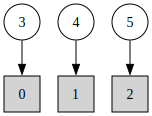

In [2]:
# Paramètres
n_candidates = 6 # nombre de candidats
n_preferences = 3  # nombre de préférences par candidat
n_extreme_candidates = 2  # nombre de candidats extrêmes

# Choisir aléatoirement quels candidats seront extrêmes
extreme_indices = np.random.choice(n_candidates, n_extreme_candidates, replace=False)
candidates = []

for i in range(n_candidates):
    preferences = []
    if i in extreme_indices:
        # Pour les candidats extrêmes, le degré d'extrémisme est variable
        extremism_factor = np.random.uniform(1.5, 3)  # facteur entre 1.5 et 3
        mu_sigma = extremism_factor  # augmente l'écart-type de mu
        sigma_scale = extremism_factor  # augmente l'échelle de sigma
    else:
        mu_sigma = 1
        sigma_scale = 1

    for pref in range(n_preferences):
        mu = norm.rvs(2, mu_sigma)
        sigma = halfnorm.rvs(scale=sigma_scale)
        mu_sigma_tuple = (np.float64(mu), np.float64(sigma))
        preferences.append(mu_sigma_tuple)

    candidates.append(tuple(preferences))

print("Contenu de candidates:")
print(candidates)

# Create agent preferences dynamically based on n_preferences
network = Network()

# Add binary-state nodes
network.add_nodes(kind="binary-state", n_nodes=n_preferences)

# Add value nodes for each binary-state node
for i in range(n_preferences):
    network.add_nodes(value_children=i)

# Plot the network
network.plot_network()

In [3]:
input_data = generate_observations(n_nodes=n_preferences, n_steps=100, scenario=1)
n_agents = 10
tonic_volatilities = np.random.normal(-3.0, 1.0, n_agents)
simulations = 10
proportions = []

while simulations > 0:
    key = random.PRNGKey(int(time.time()))
    keys = random.split(key, n_agents)
    get_votes_fn = Partial(
        get_votes,
        network=copy.deepcopy(network),
        input_data=input_data,
        n_preferences=n_preferences,
        candidates=candidates,
    )

    vmap_get_votes_fn = vmap(get_votes_fn)
    attribute, nodes_traje = vmap_get_votes_fn(tonic_volatilities, keys)
    attribute[-1]["votes"]
    proportions.append(attribute[-1]["votes"])
    simulations = simulations - 1

/var/folders/td/5r8mr8t14cn_c4w5c8ty48lw0000gn/T/ipykernel_3215/1894218974.py:17: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


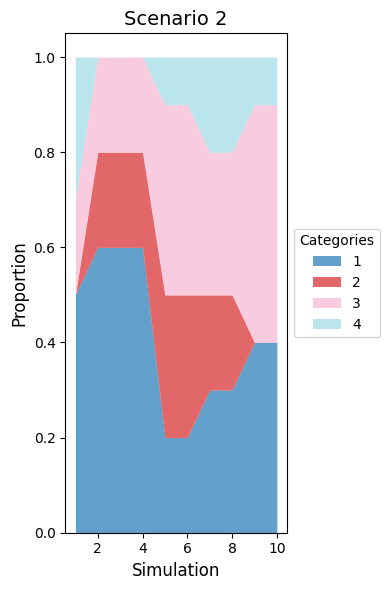

In [4]:
# Préparer les données pour le graphique
df = pd.DataFrame({
    'Simulation': np.repeat(np.arange(1, len(proportions) + 1), [len(p) for p in proportions]),
    'Category': np.concatenate([p for p in proportions])
})

# Calculer les proportions par catégorie et simulation
category_proportions = df.groupby(['Simulation', 'Category']).size().unstack(fill_value=0)
category_proportions = category_proportions.div(category_proportions.sum(axis=1), axis=0)  # Normalisation

category_proportions.plot(kind='area', stacked=True, figsize=(4, 6), colormap='tab20', alpha=0.7, linewidth=0)

plt.xlabel('Simulation', fontsize=12)
plt.ylabel('Proportion', fontsize=12)
plt.title('Scenario 2', fontsize=14)
plt.legend(title='Categories', loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()


/var/folders/td/5r8mr8t14cn_c4w5c8ty48lw0000gn/T/ipykernel_3215/2814044075.py:65: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


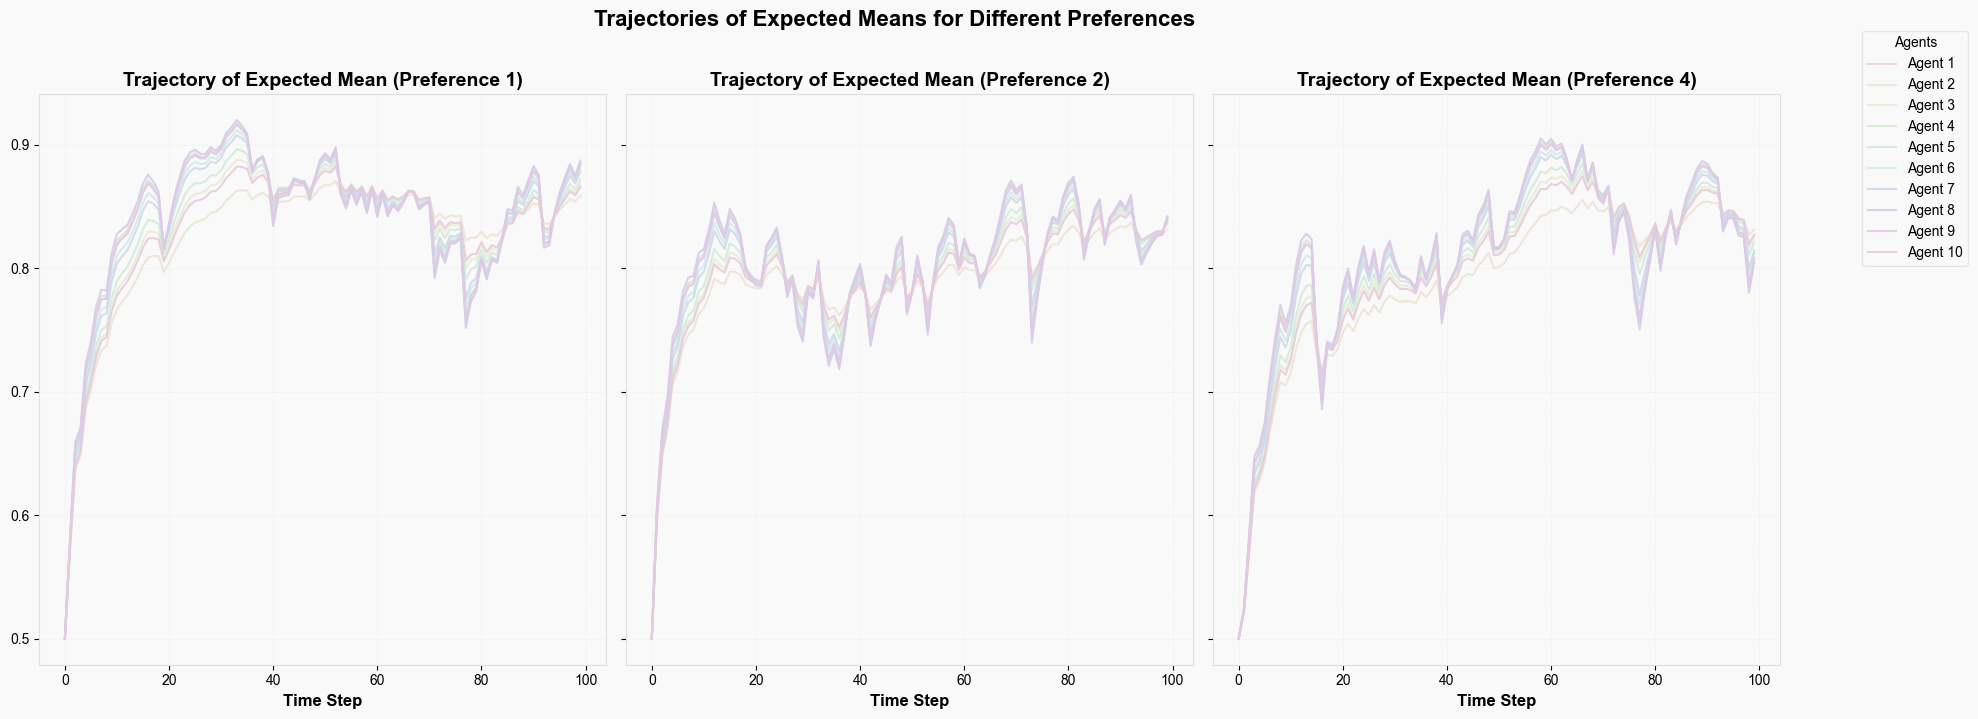

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import colorsys

# Définir les paramètres globaux pour la police
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# Définir les styles de ligne (tous des traits pleins)
line_styles = ["-"] * 10  # Tous les styles de ligne sont des traits pleins

# Créer une figure avec 3 sous-graphiques côte à côte
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True, facecolor='#f9f9f9')

# Liste des préférences et leurs indices correspondants
preferences = [0, 1, 2]  # Indices pour pref 1, pref 2, pref 4
pref_labels = ['Preference 1', 'Preference 2', 'Preference 4']

# Générer une palette de couleurs pastel
def generate_pastel_colors(n):
    pastel_colors = []
    for i in range(n):
        hue = i / n  # Distribuer les teintes uniformément
        saturation = 0.4  # Saturation légèrement réduite pour des couleurs encore plus pastel
        lightness = 0.85  # Luminosité plus élevée pour des couleurs très claires
        rgb = colorsys.hls_to_rgb(hue, lightness, saturation)
        pastel_colors.append(rgb)
    return pastel_colors

pastel_colors = generate_pastel_colors(10)

for idx, pref in enumerate(preferences):
    ax = axes[idx]
    ax.set_facecolor('#f9f9f9')  # Fond du graphique légèrement plus clair
    for n_agent in range(10):
        # Utiliser la couleur pastel correspondante
        color = pastel_colors[n_agent]
        # Définir la transparence
        alpha = 0.6 + 0.3 * (n_agent / 10)  # Variantes de transparence
        ax.plot(
            nodes_traje[pref]["expected_mean"][n_agent],
            label=f'Agent {n_agent + 1}' if idx == 0 else "",
            color=color,
            linestyle=line_styles[n_agent % len(line_styles)],
            linewidth=1.5,  # Lignes un peu plus fines
            alpha=alpha
        )
    ax.set_xlabel('Time Step', fontsize=12, fontweight='bold')
    ax.set_title(f'Trajectory of Expected Mean ({pref_labels[idx]})', fontsize=14, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4, color='#e0e0e0', linewidth=0.5)  # Grille très subtile

    # Ajouter une bordure subtile autour de chaque sous-graphique
    for spine in ax.spines.values():
        spine.set_edgecolor('#e0e0e0')  # Couleur de bordure très claire
        spine.set_linewidth(0.8)

# Ajouter une légende commune
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.1, 1), title="Agents", facecolor='#f9f9f9', edgecolor='#e0e0e0')

# Ajouter un titre global
fig.suptitle('Trajectories of Expected Means for Different Preferences', fontsize=16, fontweight='bold', y=1.02)

# Ajuster les marges et l'espacement
plt.tight_layout()
plt.subplots_adjust(top=0.9)  # Ajustement pour le titre global

plt.show()
